In [1]:
import os
import config as cfg
from utils import data

# Get dataloaders
train_dl, val_dl, test_dl = data.get_3_dataloaders()
hand_dl = data.get_test_dataloader()

# Load the model
from utils.model import load_model
MODEL_PATH = cfg.best_model_path
print(f"Loading model from: {MODEL_PATH}")
model = load_model(MODEL_PATH)

# Config for visualization
cfg.apply_matplotlib_styles()

/home/takayuki/.local/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/home/takayuki/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


 Total dataset size 	: 230
 Train dataset size 	: 138
 Val dataset size 	: 46
 Test dataset size 	: 46

Using the entire dataset as the test set. No train/val split.
Inspecting directory: /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/hand
Found 10 classes locally: ['Hydrocharis morsus-ranae', 'Myriophyllum spicatum', 'Nitellopsis obtusa', 'Nuphar variegata', 'Potamogeton crispus', 'Potamogeton gramineus', 'Potamogeton illinoensis', 'Potamogeton richardsonii', 'Potamogeton robbinsii', 'Ranunculus aquatilis']
Remapped 33 images to use canonical indices.
Total dataset size 	: 33
Calculated train size 	: 0
Calculated val size 	: 0
Calculated test size 	: 33

Test DataLoader created with 33 images from /home/takayuki/Desktop/summer2025/plants/plant_classification/../data/AquaticPlantLabData/hand.
Loading model from: /home/takayuki/Desktop/summer2025/plants/training/phase7/models/best_ood_acc_model_07-31_04-19--55_ph7_gated_attn_actual_convnextv2_t

/home/takayuki/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Sample Label =  Potamogeton gramineus

--- Running Prediction in Manuscript Mode ---


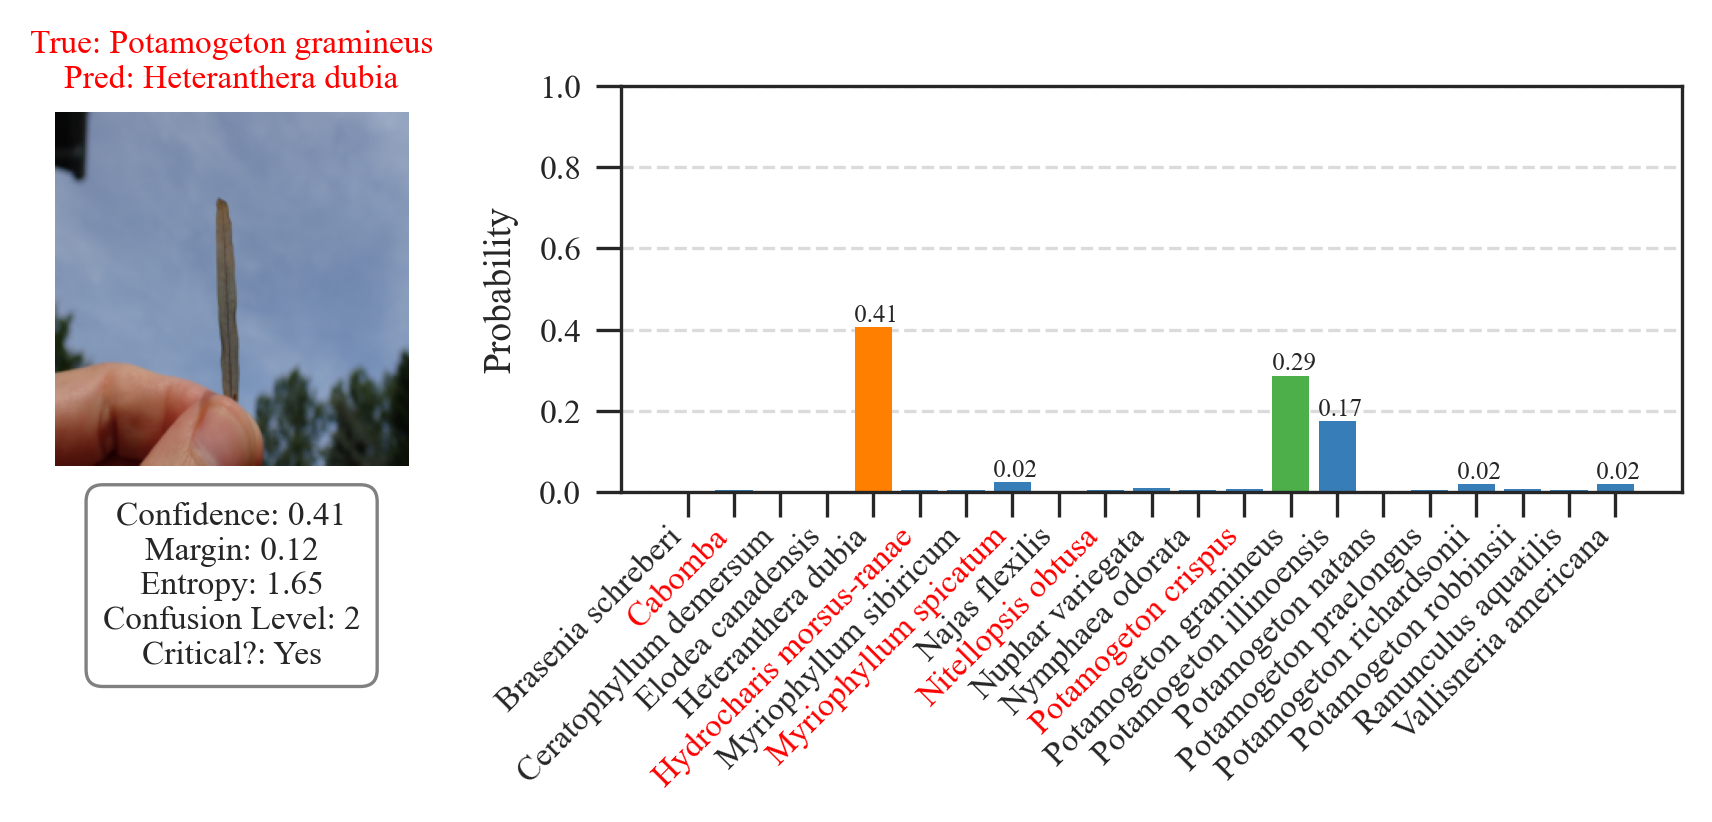


Prediction Summary:
+-----------------+--------------------+-------------------------+--------------+
| Metric          | Value              | Top-k Prediction        | Confidence   |
+=================+====================+=========================+==============+
| Predicted Class | Heteranthera dubia | Heteranthera dubia      | 0.4063       |
+-----------------+--------------------+-------------------------+--------------+
| Confidence      | 0.4063             | Potamogeton gramineus   | 0.2860       |
+-----------------+--------------------+-------------------------+--------------+
| Entropy         | 1.6452             | Potamogeton illinoensis | 0.1741       |
+-----------------+--------------------+-------------------------+--------------+
| Margin          | 0.1202             | Myriophyllum spicatum   | 0.0234       |
+-----------------+--------------------+-------------------------+--------------+
| Is Correct?     | False              | Vallisneria americana   | 0.0188    

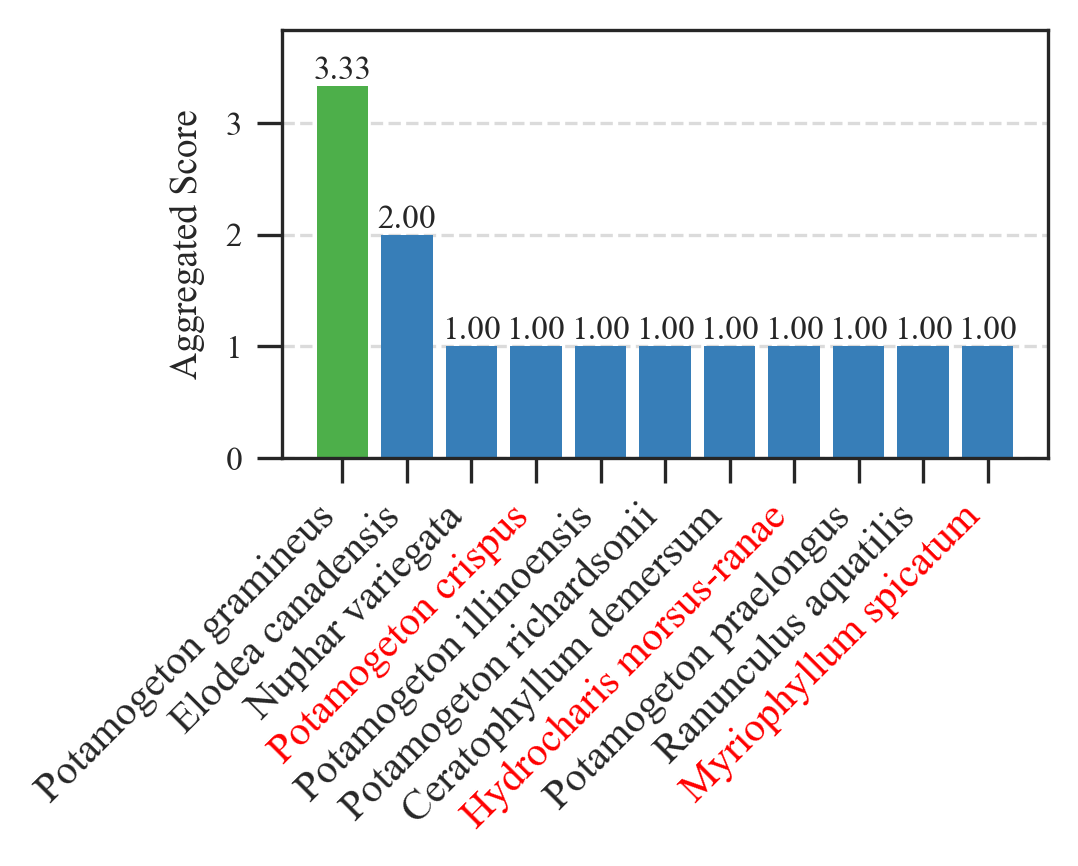


Critical Review Summary:
+------------------------+-----------------------+
| Metric                 | Value                 |
+========================+=======================+
| Final Prediction Class | Potamogeton gramineus |
+------------------------+-----------------------+
| Final Prediction Index | 13                    |
+------------------------+-----------------------+
| Number of Patches      | 111                   |
+------------------------+-----------------------+
| Is Tie?                | False                 |
+------------------------+-----------------------+
| True Label Class       | Potamogeton gramineus |
+------------------------+-----------------------+
| True Label Index       | 13                    |
+------------------------+-----------------------+
| Is Correct?            | True                  |
+------------------------+-----------------------+

Initial Prediction: Heteranthera dubia
Final Prediction after Critical Review: Potamogeton gramineus


In [2]:
# 1. Import the PredictPlants class
from utils.predict import PredictPlants

# 2. Instantiate the predictor
# You can give it a name that might appear in titles or reports later
model_name = os.path.basename(MODEL_PATH)
predictor = PredictPlants(model=model, model_name=model_name)

# 3. Get a single sample to test with
# sample_image, sample_label = next(iter(hand_dl))
index = 20
sample_image, sample_label = hand_dl.dataset[index]
sample_label = cfg.CANONICAL_INDEX_TO_CLASS[sample_label]
print("Sample Label = ", sample_label)

# The dataloader gives us a batch, so we need to select the first item.
# The squeeze() removes the batch dimension (e.g., [1, 3, 224, 224] -> [3, 224, 224])
# sample_image = sample_image[0].squeeze()
# sample_label = sample_label[0].squeeze()

# 4. Run the prediction in manuscript mode
print("\n--- Running Prediction in Manuscript Mode ---")
prediction_results = predictor.predict(
    input=sample_image, 
    true_label=sample_label, 
    display=True,             # This will call plt.show()
    return_fig=True,          # This will return the figure objects
)


In [3]:
if 'figure' in prediction_results:
    fig_main = prediction_results['figure']
    
    # Construct a descriptive filename
    true_label_str = sample_label.replace(" ", "_")
    pred_label_str = prediction_results['predicted_class_name'].replace(" ", "_")
    base_filename = f"prediction_idx{index}_True-{true_label_str}_Pred-{pred_label_str}"
    
    os.makedirs(cfg.FIGURE_SAVE_DIR, exist_ok=True)
    save_path_main = os.path.join(cfg.FIGURE_SAVE_DIR, f"{base_filename}.pdf")
    
    # Save the figure
    fig_main.savefig(save_path_main, bbox_inches='tight', dpi=cfg.FIGURE_DPI)
    print(f"\nMain figure saved to: {save_path_main}")

# --- SAVE THE CRITICAL REVIEW FIGURE (ONLY RUNS IF CRITICAL) ---
if 'critical_review_figure' in prediction_results:
    fig_crit = prediction_results['critical_review_figure']
    
    # We can reuse the base filename from above and add a suffix
    save_path_crit = os.path.join(cfg.FIGURE_SAVE_DIR, f"{base_filename}_CRITICAL_REVIEW.pdf")
    
    # Save the critical review figure
    fig_crit.savefig(save_path_crit, bbox_inches='tight', dpi=cfg.FIGURE_DPI)
    print(f"Critical review figure saved to: {save_path_crit}")


Main figure saved to: /home/takayuki/Desktop/summer2025/plants/plant_classification/../figures/prediction_idx20_True-Potamogeton_gramineus_Pred-Potamogeton_gramineus.pdf
Critical review figure saved to: /home/takayuki/Desktop/summer2025/plants/plant_classification/../figures/prediction_idx20_True-Potamogeton_gramineus_Pred-Potamogeton_gramineus_CRITICAL_REVIEW.pdf
